## Import libraries and data

In [2]:
# Import libraries.

!pip install palmerpenguins
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import metrics
import statsmodels.api as sm 
from statsmodels.formula.api import ols
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, silhouette_score
import scipy.stats as stats
import imblearn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from itertools import product

In [3]:
# Import data.
from palmerpenguins import load_penguins


penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


## Explore the data

In [6]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [7]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [8]:
penguins['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [9]:
penguins['species'].unique().tolist()

['Adelie', 'Gentoo', 'Chinstrap']

Will need to balance the dataset!

In [11]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [12]:
penguins['sex'].value_counts()

sex
male      168
female    165
Name: count, dtype: int64

In [13]:
penguins.groupby(['species', 'island']).size().reset_index(name='count')

,species,island,count
0,Adelie,Biscoe,44
1,Adelie,Dream,56
2,Adelie,Torgersen,52
3,Chinstrap,Dream,68
4,Gentoo,Biscoe,124


In [14]:
penguins.value_counts(['species', 'sex'])

species    sex   
Adelie     female    73
           male      73
Gentoo     male      61
           female    58
Chinstrap  female    34
           male      34
Name: count, dtype: int64

In [15]:
penguins.value_counts('year')

year
2009    120
2008    114
2007    110
Name: count, dtype: int64

In [16]:
# Check for full duplicated rows.

penguins[penguins.duplicated()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year


No full duplicated rows.

In [18]:
corr = penguins.drop(columns=['year']).corr(numeric_only = True)

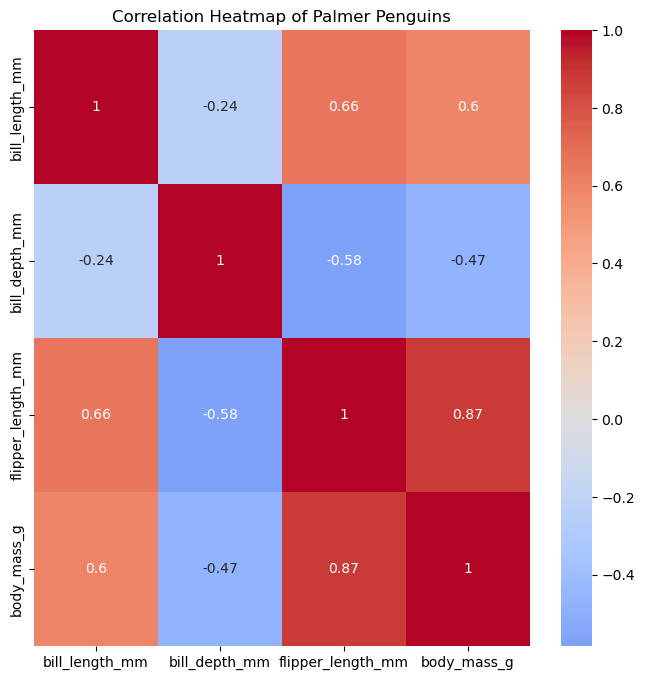

In [19]:
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Palmer Penguins")
plt.show()

In [20]:
selected_penguins = penguins[
                  (penguins['species'].isin(['Gentoo', 'Adelie'])) & (penguins['body_mass_g'] >= 4000)]

In [21]:
selected_penguins['species'].unique()

array(['Adelie', 'Gentoo'], dtype=object)

In [22]:
selected_penguins.groupby(['species', 'island', 'sex']).size().reset_index(name='count')

,species,island,sex,count
0,Adelie,Biscoe,male,11
1,Adelie,Dream,male,14
2,Adelie,Torgersen,male,13
3,Gentoo,Biscoe,female,57
4,Gentoo,Biscoe,male,61


In [23]:
# Scatterplot function.

def scatterplot(df, x_col, y_col, hue_col, title, x_label, y_label, palette, **kwargs):
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue_col, palette=palette)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title, fontweight='bold')
    plt.legend(title=hue_col.title())
    plt.show()

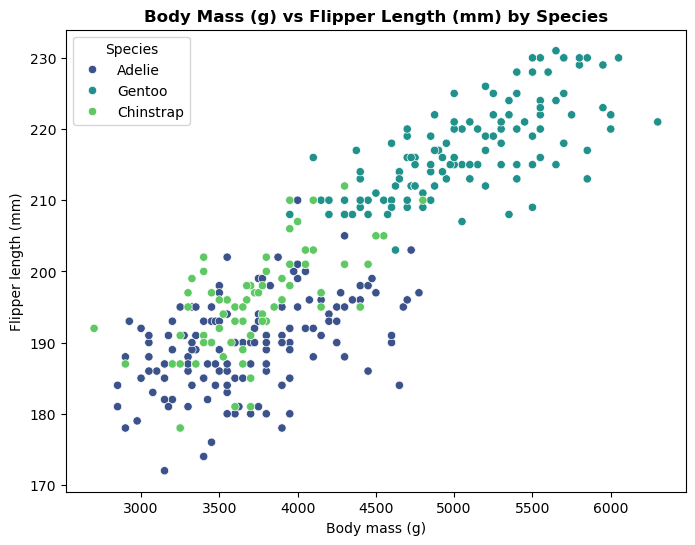

In [24]:
scatterplot(penguins, 'body_mass_g', 'flipper_length_mm', 'species', 
            'Body Mass (g) vs Flipper Length (mm) by Species', 'Body mass (g)', 
            'Flipper length (mm)', 'viridis')

In [25]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')

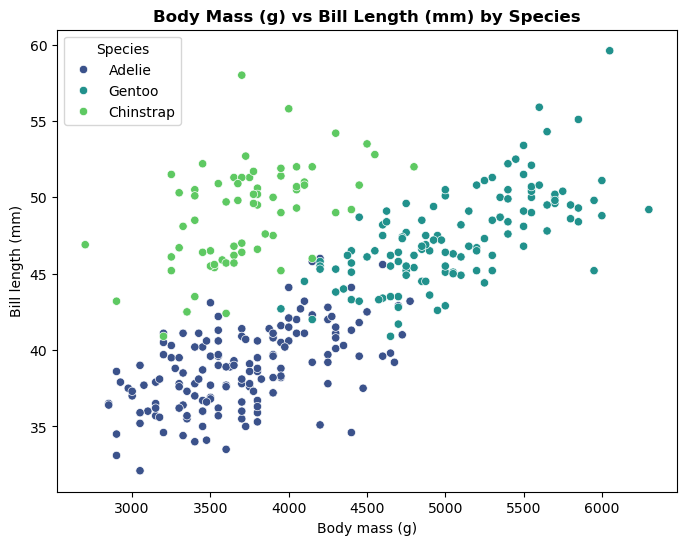

In [26]:
scatterplot(penguins, 'body_mass_g', 'bill_length_mm', 'species', 
            'Body Mass (g) vs Bill Length (mm) by Species', 'Body mass (g)', 
            'Bill length (mm)', 'viridis')

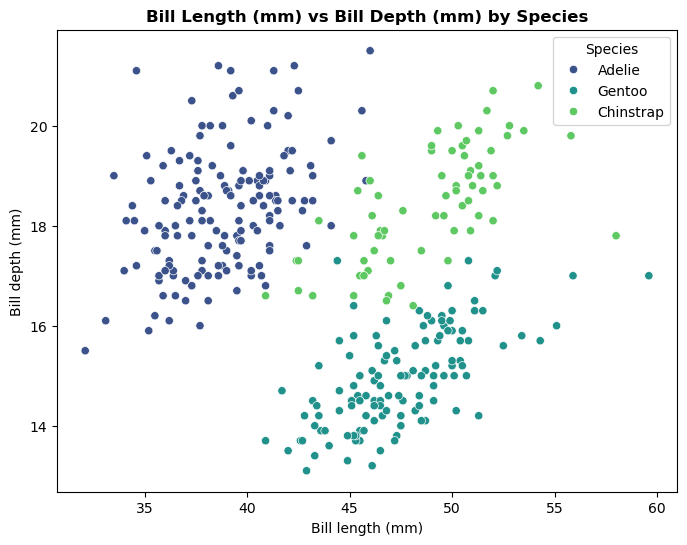

In [27]:
scatterplot(penguins, 'bill_length_mm', 'bill_depth_mm', 'species', 
            'Bill Length (mm) vs Bill Depth (mm) by Species', 'Bill length (mm)',
            'Bill depth (mm)', 'viridis')

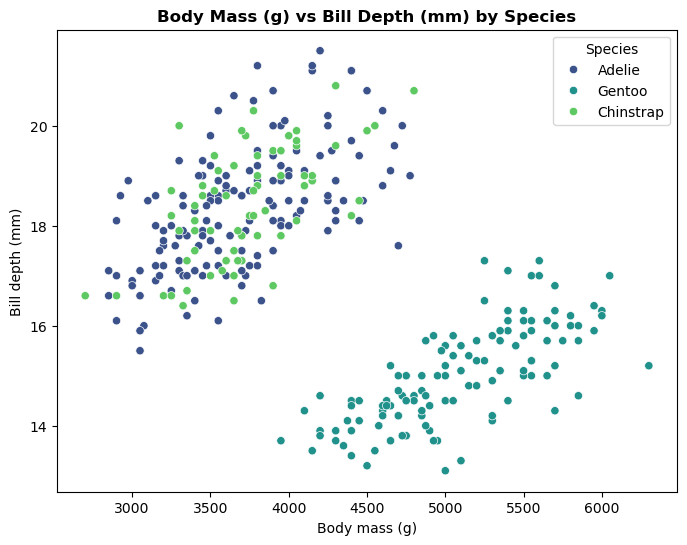

In [28]:
scatterplot(penguins, 'body_mass_g', 'bill_depth_mm', 'species', 
            'Body Mass (g) vs Bill Depth (mm) by Species', 'Body mass (g)',
            'Bill depth (mm)', 'viridis')

## Build classification model

### Multinominal logistic regression

#### Prepare the data

1. Combine sex and species into one column. This is not ideal with the size of the dataset being quite small as there are then 6 categories to predict, but it will work better for the Tableau visualisation. I wouldn't do this in a business context, only here because it's just for fun as it does decrease the accuracy of the model.

2. Drop island as a column - it makes the Tableau viz less user friendly and penguins are highly unlikely to vary much within the same species between islands (the islands are close to each other).

3. Drop year as well as the measurements are unlikely to vary across the space of a few years.


In [33]:
# Combine sex and species columns.
penguins['sex_species'] = penguins['sex'] + ' ' + penguins['species']

In [34]:
# View sex_species.
penguins['sex_species'].value_counts()

sex_species
male Adelie         73
female Adelie       73
male Gentoo         61
female Gentoo       58
female Chinstrap    34
male Chinstrap      34
Name: count, dtype: int64

In [35]:
# Change sex_species to title case.
penguins['sex_species'] = penguins['sex_species'].str.title()

In [36]:
# View sex_species.
penguins['sex_species'].value_counts() 

sex_species
Male Adelie         73
Female Adelie       73
Male Gentoo         61
Female Gentoo       58
Female Chinstrap    34
Male Chinstrap      34
Name: count, dtype: int64

In [37]:
# Drop island and year columns.
penguins.drop(columns=['island', 'year'], inplace=True)

In [38]:
# View penguins.
penguins.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,sex_species
0,Adelie,39.1,18.7,181.0,3750.0,male,Male Adelie
1,Adelie,39.5,17.4,186.0,3800.0,female,Female Adelie
2,Adelie,40.3,18.0,195.0,3250.0,female,Female Adelie
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,36.7,19.3,193.0,3450.0,female,Female Adelie


In [39]:
# Drop species and sex columns.

penguins2 = penguins.drop(columns=['species', 'sex'])

In [40]:
# View penguins2.

penguins2.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex_species
0,39.1,18.7,181.0,3750.0,Male Adelie
1,39.5,17.4,186.0,3800.0,Female Adelie
2,40.3,18.0,195.0,3250.0,Female Adelie
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,Female Adelie


In [41]:
# Drop rows where sex_species is null.

penguins2.dropna(subset=['sex_species'], inplace=True)

In [42]:
# Set the independent variable.
X = penguins2.drop(columns=['sex_species'])

# Set the dependent variable.
y = penguins2['sex_species']

# Has the sex_species column been dropped?
print(list(X.columns.values))

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


Note before splitting into train and test that sex_species is inbalanced. However, it's not really bad but the dataset is small so synthetically generating data using SMOTE is risky and risks making the model unreliable. I'll used stratify when splitting into training and testing which ast least preserves the same proportions in each class in both the training and testing sets.

In [44]:
# Specify the train and test data sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 1, stratify=y) 

Scale the data as the ranges of the independent variables are quite different to each other.

In [46]:
# Scale the data.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
# Define and fit the model
MLR = LogisticRegression(random_state=42, 
                         penalty=None, 
                         solver='newton-cg').fit(X_train, y_train)

In [48]:
# Get predictions and parameters
preds = MLR.predict(X_test)
params = MLR.get_params()

In [49]:
# Print model details
print(params)
print("Intercept: \n", MLR.intercept_)
print("Coefficients: \n", MLR.coef_)

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': None, 'random_state': 42, 'solver': 'newton-cg', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
Intercept: 
 [  6.6636886  -12.85168929  15.6946861   13.55715072 -20.19996381
  -2.86387232]
Coefficients: 
 [[-49.24977967  11.93664759   5.30268515  12.74665694]
 [ 48.62818899  -8.02314433 -14.48677264 -31.86857904]
 [ -4.52205701 -12.60953546   6.01685271   4.9613544 ]
 [-44.6710938   14.40269392   5.28365695  18.78701925]
 [ 54.19783619  -3.89777357 -15.6480403  -29.59599931]
 [ -4.3830947   -1.80888815  13.53161814  24.96954777]]


In [50]:
# Evaluate the model
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.91
                  precision    recall  f1-score   support

   Female Adelie       0.87      0.91      0.89        22
Female Chinstrap       0.82      0.90      0.86        10
   Female Gentoo       0.86      1.00      0.92        18
     Male Adelie       1.00      0.86      0.93        22
  Male Chinstrap       0.91      1.00      0.95        10
     Male Gentoo       1.00      0.83      0.91        18

        accuracy                           0.91       100
       macro avg       0.91      0.92      0.91       100
    weighted avg       0.92      0.91      0.91       100



91% is a good accuracy.

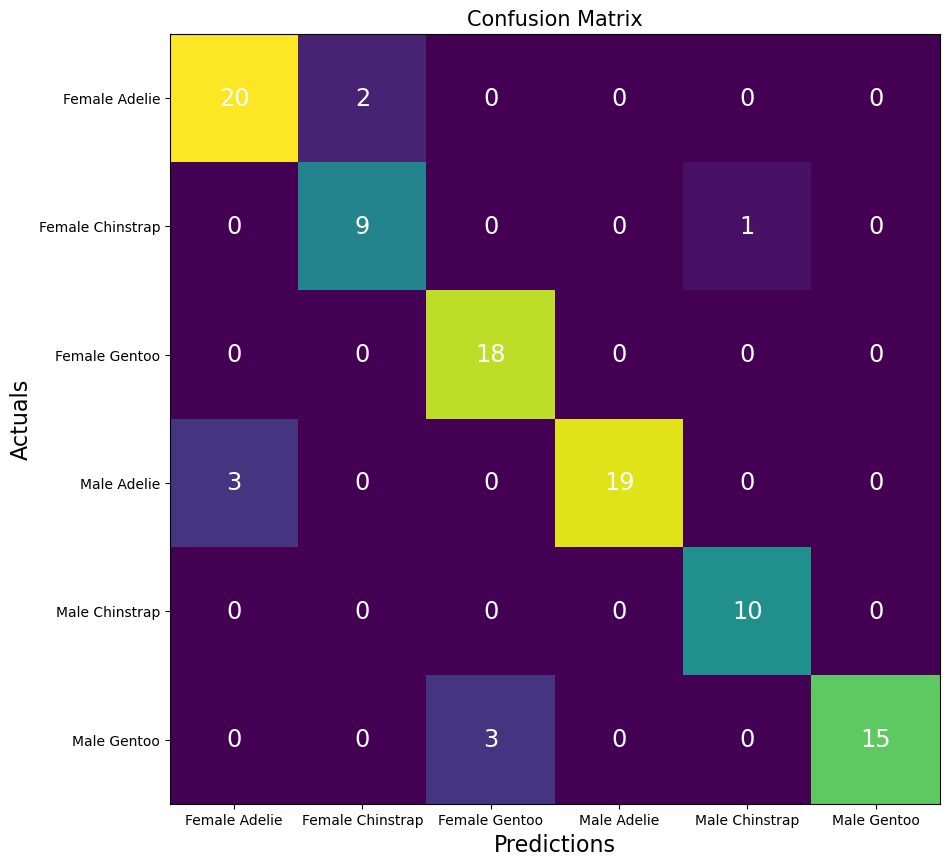

In [52]:
# Create confusion matrix.
cm = confusion_matrix(y_test, preds)  


fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks=(0, 1, 2, 3, 4, 5),
             ticklabels=('Female Adelie', 'Female Chinstrap', 'Female Gentoo', 'Male Adelie', 'Male Chinstrap', 'Male Gentoo'))
ax.yaxis.set(ticks=(0, 1, 2, 3, 4, 5),
             ticklabels=('Female Adelie', 'Female Chinstrap', 'Female Gentoo', 'Male Adelie', 'Male Chinstrap', 'Male Gentoo'))


for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j],
                ha='center',
                va='center',
                color='white',
                size='xx-large')
        
# Set the labels.
plt.xlabel('Predictions', fontsize=16)
plt.ylabel('Actuals', fontsize=16)
plt.title('Confusion Matrix', fontsize=15)

plt.show()

Most of the time the model predicts incorrectly, it predicts the correct species, but not the correct sex.

### Generating the CSV file of all possible predictions (within defined ranges and steps)

In [55]:
# What are the min and max values for each independent variable?

penguins2[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].agg(['min', 'max'])

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
min,32.1,13.1,172.0,2700.0
max,59.6,21.5,231.0,6300.0


In [56]:
# Define ranges using  min/max values (rounded to a whole number to make it more user friendly on Tableau).

bill_length_vals    = np.arange(32, 60, 1)
bill_depth_vals     = np.arange(13, 22, 1)
flipper_length_vals = np.arange(172, 231, 1)
body_mass_vals      = np.arange(2700, 6300, 100)

In [57]:
# Create every combination
combos = pd.DataFrame(
    list(product(bill_length_vals, bill_depth_vals, flipper_length_vals, body_mass_vals)),
    columns=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
)

print(f"Total combinations: {len(combos):,}")

Total combinations: 535,248


In [58]:
# Transform raw numbers into the same scale the model was trained on.

combos_scaled = scaler.transform(combos)

In [59]:
# Predict on the scaled version.

predictions = MLR.predict(combos_scaled)

In [60]:
# Add predictions as a column

combos['prediction'] = predictions

In [61]:
# Save to CSV

combos.to_csv('penguin_predictions.csv', index=False)